In [2]:
### PROBLEM 1 ###

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [4]:
n_values=np.arange(1, 11)
K_values=4**n_values
print("n_values:", n_values)
print("K_values:", K_values)

n_values: [ 1  2  3  4  5  6  7  8  9 10]
K_values: [      4      16      64     256    1024    4096   16384   65536  262144
 1048576]


In [5]:
mean = 0.5
variance = 1/12
skewness = 0
kurt = -6/5

In [6]:
mean_samp = []
variance_samp = []
skewness_samp = []
kurtosis_samp = []

In [8]:
# rng = np.random.default_rng()

# for K in K_values:
#     x = rng.uniform(0, 1, size=K)

#     mean_samp.append(np.mean(x))
#     variance_samp.append(np.var(x))
#     skewness_samp.append(skew(x))
#     kurtosis_samp.append(kurtosis(x))
rng = np.random.default_rng()
x = rng.uniform(0, 1, size=K_values[-1])

for K in K_values:


    mean_samp.append(np.mean(x[:K]))
    variance_samp.append(np.var(x[:K]))
    skewness_samp.append(skew(x[:K]))
    kurtosis_samp.append(kurtosis(x[:K]))

In [9]:
log2K = np.log2(K_values)

<function matplotlib.pyplot.show(close=None, block=None)>

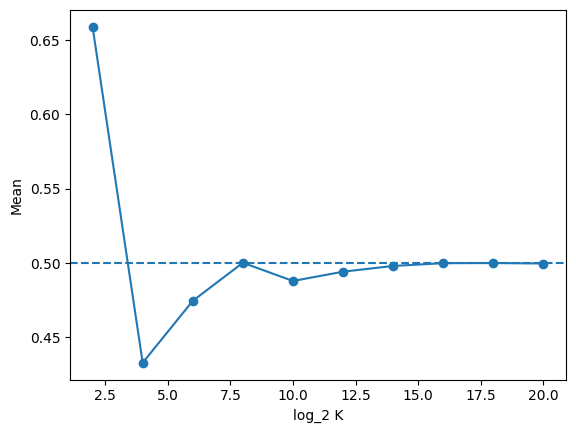

In [10]:
# mean plot
plt.figure()
plt.plot(log2K, mean_samp, 'o-', label='Sample')
plt.axhline(mean, linestyle='--', label='Predicted Value')
plt.xlabel('log_2 K')
plt.ylabel('Mean')
plt.legend
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

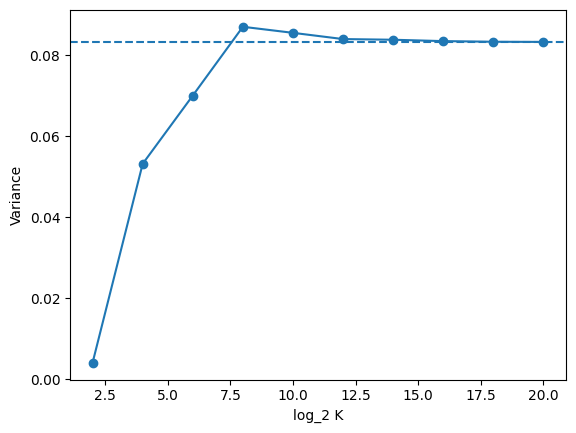

In [11]:
# variance plot
plt.figure()
plt.plot(log2K, variance_samp, 'o-', label='Sample')
plt.axhline(variance, linestyle='--', label='Predicted Value')
plt.xlabel('log_2 K')
plt.ylabel('Variance')
plt.legend
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

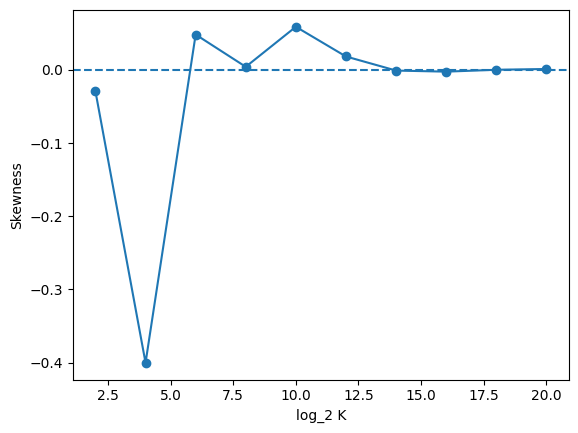

In [12]:
# skewness plot
plt.figure()
plt.plot(log2K, skewness_samp, 'o-', label='Sample')
plt.axhline(skewness, linestyle='--', label='Predicted Value')
plt.xlabel('log_2 K')
plt.ylabel('Skewness')
plt.legend
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

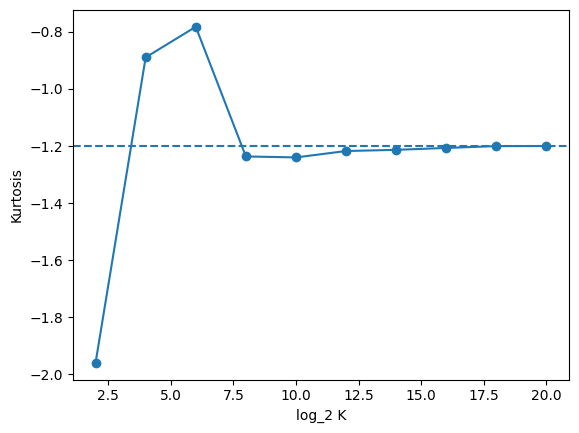

In [13]:
# kurtosis plot
plt.figure()
plt.plot(log2K, kurtosis_samp, 'o-', label='Sample')
plt.axhline(kurt, linestyle='--', label='Predicted Value')
plt.xlabel('log_2 K')
plt.ylabel('Kurtosis')
plt.legend
plt.show

In [6]:
### PROBLEM 2 ###

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
n_steps = 25000
x_initial = 0
samples = []

In [34]:
def log_p(x):
    mu = 2
    var = 2
    return -0.5 * (x - mu)**2 / var #

In [35]:
for n in range(n_steps):
    x_proposal = np.random.normal(loc=x_initial, scale=1)

    log_alpha = log_p(x_proposal) - log_p(x_initial)
    alpha = np.exp(log_alpha)

    if np.random.rand() < min(1, alpha):
        x_initial = x_proposal

    samples.append(x_initial)

samples = np.array(samples)

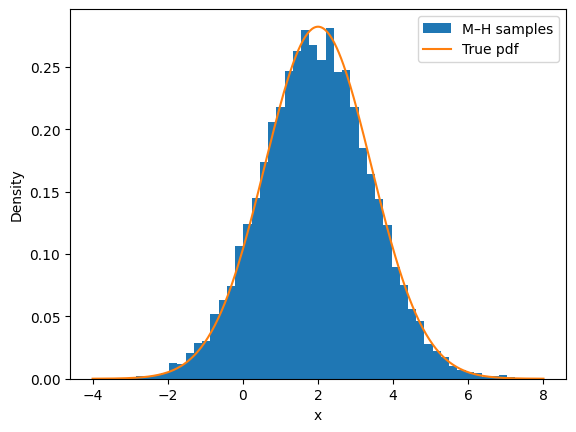

In [37]:
x_plot = np.linspace(-4, 8, 400)
true_pdf = (1 / np.sqrt(2 * np.pi * 2)) * np.exp(-(x_plot - 2)**2 / (2 * 2))

plt.figure()
plt.hist(samples, bins=50, density=True, label="M–H samples")
plt.plot(x_plot, true_pdf, label="True pdf")

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [38]:
### PROBLEM 3 ###

In [37]:
n_steps = 25000
x_initial = -4
samples = []

In [38]:
def log_p(x):
    if 3 < x < 7:
        return 0
    else:
        return -np.inf

In [39]:
for n in range(n_steps):
    x_proposal = np.random.normal(loc=x_initial, scale=1)

    log_alpha = log_p(x_proposal) - log_p(x_initial)

    if np.random.rand() < min(1, np.exp(log_alpha)):
        x_initial = x_proposal

    samples.append(x_initial)

samples = np.array(samples)

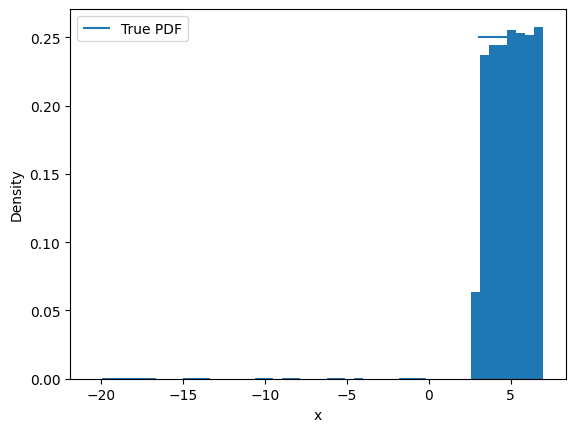

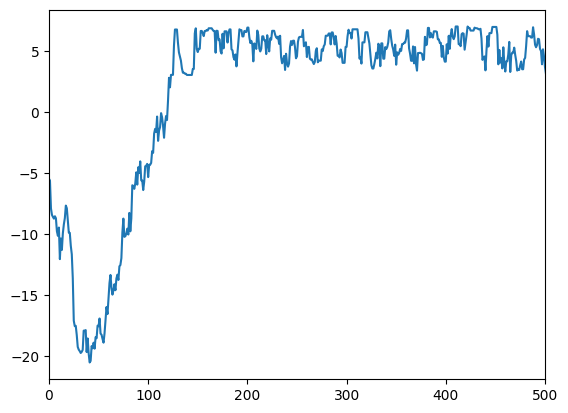

In [47]:
plt.hist(samples, bins=50, density=True)

plt.hlines(1/4, 3, 7, label="True PDF")

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

steps = np.arange(samples.size)
plt.plot(steps, samples)
plt.xlim(0,500)
plt.show()


In [46]:
### PROBLEM 4 ###

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [48]:
def mh_sampler_2d(log_p, n_steps=20000, burn=2000):
    x = np.array([0,0])
    samples = []

    for _ in range(n_steps):
        x_prop = x + np.random.normal(size=2)

        log_alpha = log_p(x_prop) - log_p(x)
        if np.log(np.random.rand()) < log_alpha:
            x = x_prop

        samples.append(x.copy())

    samples = np.array(samples)
    return samples[burn:]

In [49]:
V = np.array([[2, 1.2],[1.2,2]])
V_inv = np.linalg.inv(V)

def log_p_gaussian(x):
    return -0.5 * x.T @ V_inv @ x

In [50]:
def log_p_tophat(x):
    if 3 < x[0] < 7 and 1 < x[1] < 9:
        return 0
    else:
        return -np.inf

In [64]:
samples_gauss = mh_sampler_2d(log_p_gaussian)
samples_tophat = mh_sampler_2d(log_p_tophat, burn=0)

In [65]:
def plot_results(samples, title):
    x_vals = samples[:, 0]
    y_vals = samples[:, 1]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram for x
    axs[0].hist(x_vals, bins=50, density=True)
    axs[0].set_title("Histogram of x")

    # Histogram for y
    axs[1].hist(y_vals, bins=50, density=True)
    axs[1].set_title("Histogram of y")

    # 2D scatter
    axs[2].scatter(x_vals, y_vals, s=2, alpha=0.5)
    axs[2].set_title("2D Scatter")
    axs[2].set_xlabel("x")
    axs[2].set_ylabel("y")

    plt.tight_layout()
    plt.show()

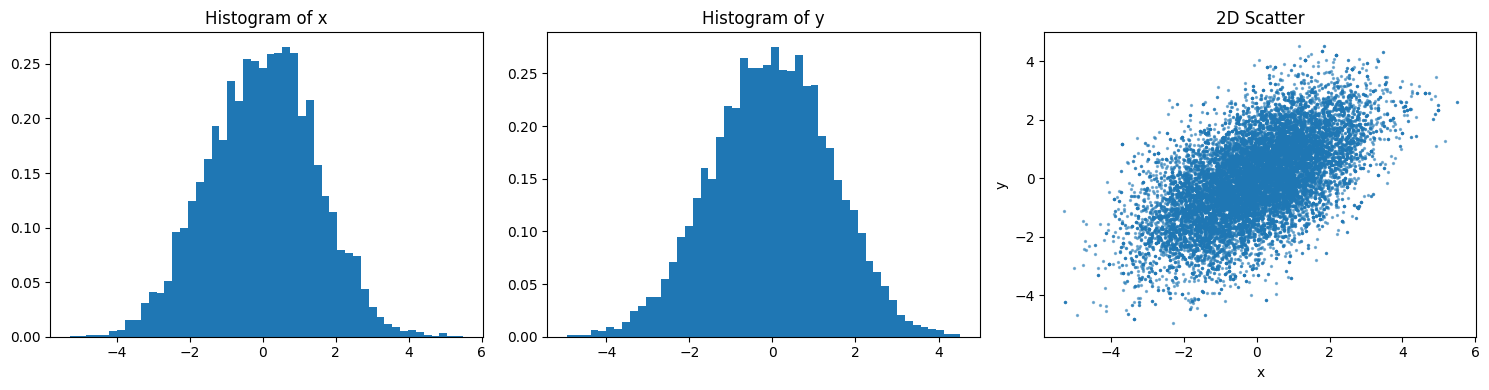

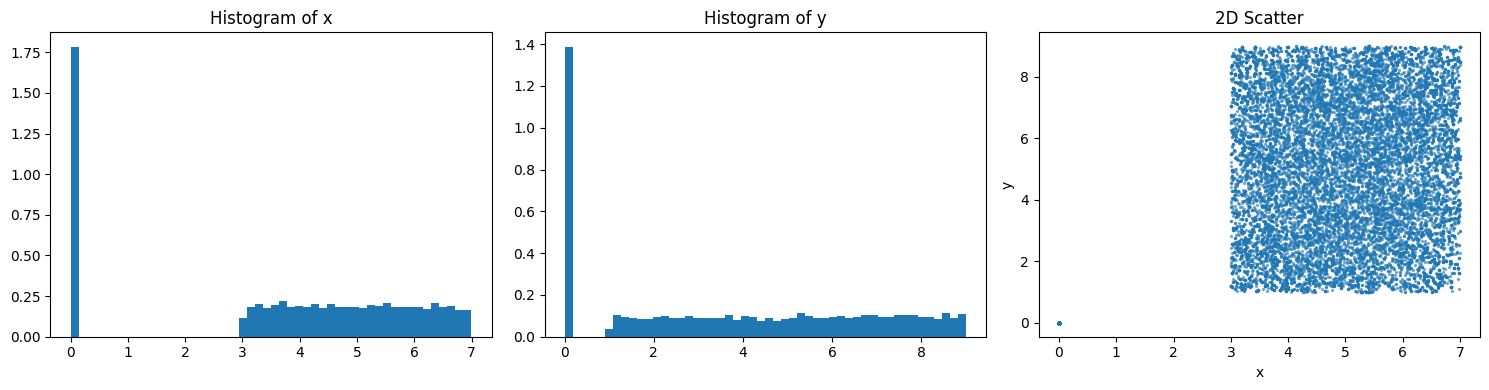

In [66]:
plot_results(samples_gauss, "Correlated Gaussian Target")
plot_results(samples_tophat, "Rectangular Top-Hat Target")

In [67]:
print(samples_tophat)

[[0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 ...
 [5.48945022 3.80414335]
 [4.08990305 2.22792759]
 [4.08990305 2.22792759]]


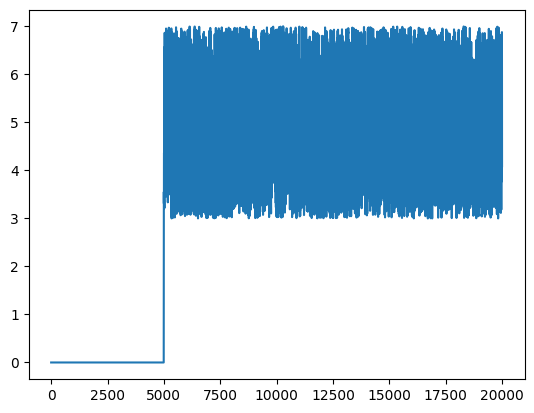

In [68]:
steps = np.arange(samples_tophat[:,0].size)
plt.plot(steps, samples_tophat[:, 0])
plt.show()